# BÀI THI / KIỂM TRA: THUẬT TOÁN K-NEAREST NEIGHBORS (K-NN)
## HỌC PHẦN: HỌC MÁY VÀ KHAI PHÁ DỮ LIỆU (ML-DUT)
---
**Thông tin sinh viên:**
- Họ và tên: **Nguyễn Trung Kiên**
- Mã số sinh viên: **102230023**
- Lớp / Khoa: **Khoa Công nghệ Thông tin - Trường Đại học Bách khoa, ĐH Đà Nẵng**
- Mã đề / Bài tập: **Exercise 01 (KNN Classification from Scratch)**

---
### Bố cục bài làm:
1. **Phần I (Toán học & Dữ liệu):** Trích xuất tọa độ không gian và định nghĩa độ đo mêtric.
2. **Phần II (Câu a - Bảng tính chi tiết):** Trình bày bảng tính toán khoảng cách và phân lớp từng bước cho 6 điểm ($A \to F$) qua 6 cấu hình.
3. **Phần III (Câu b - Phân tích chuyên sâu):** Đánh giá tác động của $k$, mêtric Euclidean vs Manhattan và hiện tượng hòa phiếu.
4. **Phần IV (Câu c - Lập trình Scratch & Demo):** Cài đặt thuật toán KNN từ đầu bằng Python và chạy kiểm chứng cho điểm $E$ ($k=5$).

## PHẦN I: CƠ SỞ TOÁN HỌC & SỐ HÓA DỮ LIỆU

### 1.1. Công thức khoảng cách
Với điểm truy vấn $u = (x_u, y_u)$ và điểm huấn luyện $v = (x_v, y_v)$:
- **Khoảng cách Euclidean ($L_2$ norm):**
  $$d_E(u, v) = \|u - v\|_2 = \sqrt{(x_u - x_v)^2 + (y_u - y_v)^2}$$
- **Khoảng cách Manhattan ($L_1$ norm):**
  $$d_M(u, v) = \|u - v\|_1 = |x_u - x_v| + |y_u - y_v|$$

### 1.2. Khai báo thư viện & Tập dữ liệu Figure 1

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 31 điểm huấn luyện từ Hình 1 (Figure 1)
TRAIN_DATA = [
    # Red Triangle (8 điểm)
    ((1, 9), 'Red Triangle'), ((3, 9), 'Red Triangle'), ((4, 7), 'Red Triangle'),
    ((2, 4), 'Red Triangle'), ((1, 2), 'Red Triangle'), ((3, 1), 'Red Triangle'),
    ((6, 5), 'Red Triangle'), ((6, 2), 'Red Triangle'),
    
    # Blue Square (9 điểm)
    ((1, 7), 'Blue Square'), ((3, 7), 'Blue Square'), ((7, 8), 'Blue Square'),
    ((9, 9), 'Blue Square'), ((8, 5), 'Blue Square'), ((5, 3), 'Blue Square'),
    ((8, 3), 'Blue Square'), ((9, 2), 'Blue Square'), ((8, 1), 'Blue Square'),
    
    # Green Star (5 điểm)
    ((4, 8), 'Green Star'), ((8, 7), 'Green Star'), ((4, 4), 'Green Star'),
    ((2, 1), 'Green Star'), ((8, 2), 'Green Star'),
    
    # Black Heart (9 điểm)
    ((2, 5), 'Black Heart'), ((3, 5), 'Black Heart'), ((4, 5), 'Black Heart'),
    ((1, 3), 'Black Heart'), ((3, 3), 'Black Heart'), ((2, 2), 'Black Heart'),
    ((4, 2), 'Black Heart'), ((1, 1), 'Black Heart'), ((5, 1), 'Black Heart')
]

# 6 điểm kiểm thử chưa gán nhãn
TEST_POINTS = {
    'A': (2, 8), 'B': (6, 7), 'C': (7, 5),
    'D': (2, 3), 'E': (7, 2), 'F': (4, 1)
}

print(f"Đã khởi tạo thành công: {len(TRAIN_DATA)} mẫu huấn luyện (4 lớp) và {len(TEST_POINTS)} điểm kiểm thử.")

Đã khởi tạo thành công: 31 mẫu huấn luyện (4 lớp) và 6 điểm kiểm thử.


### 1.3. Trực quan hóa không gian dữ liệu kiểm tra nhanh (Data Plot)
Vẽ nhanh không gian tọa độ 2D giúp giám khảo đối chiếu trực quan vị trí tương đối giữa các điểm.

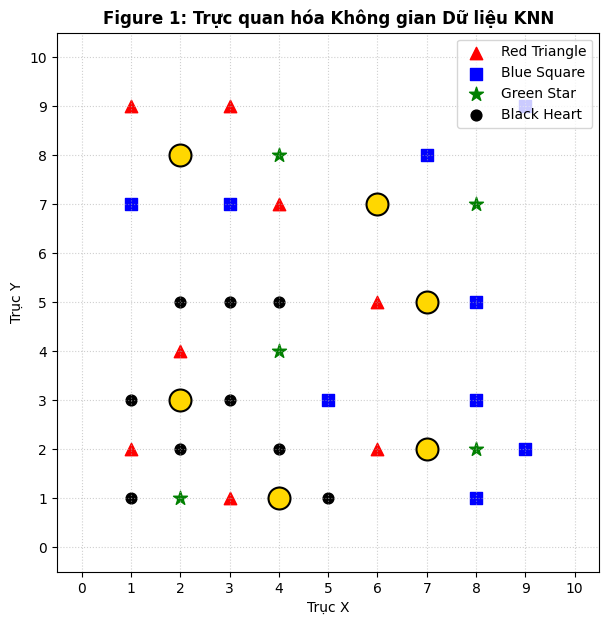

In [2]:
plt.figure(figsize=(7, 7))
styles = {
    'Red Triangle': {'c': 'red', 'm': '^', 's': 80},
    'Blue Square': {'c': 'blue', 'm': 's', 's': 70},
    'Green Star': {'c': 'green', 'm': '*', 's': 110},
    'Black Heart': {'c': 'black', 'm': 'o', 's': 60}
}

for label, st in styles.items():
    pts = [p[0] for p in TRAIN_DATA if p[1] == label]
    plt.scatter([p[0] for p in pts], [p[1] for p in pts], color=st['c'], marker=st['m'], s=st['s'], label=label)

for name, pt in TEST_POINTS.items():
    plt.scatter(pt[0], pt[1], s=250, c='gold', edgecolors='black', linewidths=1.5, zorder=5)
    plt.text(pt[0], pt[1], name, weight='bold', ha='center', va='center', fontsize=9)

plt.xlim(-0.5, 10.5); plt.ylim(-0.5, 10.5)
plt.xticks(range(11)); plt.yticks(range(11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.title("Figure 1: Trực quan hóa Không gian Dữ liệu KNN", weight='bold')
plt.xlabel("Trục X"); plt.ylabel("Trục Y")
plt.legend(loc='upper right')
plt.show()

## PHẦN II (CÂU A): BẢNG TÍNH TOÁN KHOẢNG CÁCH VÀ PHÂN LỚP TỪNG BƯỚC

> **Nguyên tắc:** Mỗi điểm kiểm thử được đánh giá hoàn toàn độc lập trên tập 31 điểm ban đầu, không sử dụng kết quả vừa phân loại để gán cho các điểm tiếp theo.

### 2.1. Chi tiết tính toán láng giềng và phân lớp cho từng điểm

#### 1. Điểm A (2, 8):
- **Euclidean:**
  - Top 4 láng giềng: $(1, 7)$ [Sq, $\sqrt{2}$], $(1, 9)$ [Tr, $\sqrt{2}$], $(3, 7)$ [Sq, $\sqrt{2}$], $(3, 9)$ [Tr, $\sqrt{2}$] $\rightarrow$ **Hòa phiếu (2 Sq - 2 Tr)**.
  - Thứ 5: $(4, 8)$ [St, $2.0$] $\rightarrow$ $k=5$ vẫn **Hòa phiếu (2 Sq - 2 Tr - 1 St)**.
  - Thứ 6: $(4, 7)$ [Tr, $\sqrt{5} \approx 2.236$] $\rightarrow$ $k=6$ dự đoán: **Red Triangle (3 Tr - 2 Sq - 1 St)**.
- **Manhattan:**
  - Cả 5 điểm $(1, 7), (1, 9), (3, 7), (3, 9), (4, 8)$ đều có khoảng cách bằng **2.0**.
  - Với $k=4$ và $k=5$: **Hòa phiếu (2 Sq - 2 Tr)**. Với $k=6$: nhận thêm $(2, 5)$ [Ht, 3] hoặc $(4, 7)$ [Tr, 3], vẫn duy trì tình trạng hòa phiếu hoặc phụ thuộc vào tie-break.

#### 2. Điểm B (6, 7):
- **Euclidean:**
  - Láng giềng: #1 $(7, 8)$ [Sq, $\sqrt{2}$], #2 $(4, 7)$ [Tr, $2.0$], #3 $(6, 5)$ [Tr, $2.0$], #4 $(8, 7)$ [St, $2.0$], #5 $(4, 8)$ [St, $\sqrt{5}$].
  - $k=4$: **Red Triangle** (2 Tr, 1 Sq, 1 St).
  - $k=5$: **Hòa phiếu (Tie: 2 Red Triangle / 2 Green Star)**.
  - $k=6$: Thu nạp thêm điểm ở khoảng cách $\sqrt{8}$ $\rightarrow$ **Hòa phiếu**.
- **Manhattan:**
  - Láng giềng khoảng cách 2.0: $(4, 7)$ [Tr], $(6, 5)$ [Tr], $(7, 8)$ [Sq], $(8, 7)$ [St].
  - $k=4$: **Red Triangle** (2 Tr, 1 Sq, 1 St).
  - $k=5$: Nhận thêm $(3, 7)$ [Sq] hoặc $(4, 8)$ [St] (cùng $d=3$) $\rightarrow$ **Hòa phiếu**.
  - $k=6$: Cả 3 lớp cùng đạt 2 phiếu $\rightarrow$ **Hòa 3 bên (3-way Tie)**.

#### 3. Điểm C (7, 5):
- Láng giềng gần nhất: #1 $(6, 5)$ [Tr, $d=1$], #2 $(8, 5)$ [Sq, $d=1$], #3 $(8, 3)$ [Sq, $d_E=\sqrt{5}$], #4 $(8, 7)$ [St, $d_E=\sqrt{5}$], #5 $(5, 3)$ [Sq, $d_E=\sqrt{8}$].
- Cả Euclidean và Manhattan qua $k = 4, 5, 6$: **Blue Square** luôn thắng áp đảo ($2/4, 3/5, 3/6$).

#### 4. Điểm D (2, 3):
- Láng giềng trực tiếp: 4 điểm cách đúng 1 đơn vị gồm $(1, 3)$ [Ht], $(2, 2)$ [Ht], $(3, 3)$ [Ht] và $(2, 4)$ [Tr].
- Cả Euclidean và Manhattan qua $k = 4, 5, 6$: **Black Heart** thắng tuyệt đối ($3/4, 3/5, 3/6$).

#### 5. Điểm E (7, 2):
- Láng giềng gần nhất: #1 $(6, 2)$ [Tr, $d=1$], #2 $(8, 2)$ [St, $d=1$], #3 $(8, 1)$ [Sq, $d_E=\sqrt{2}$], #4 $(8, 3)$ [Sq, $d_E=\sqrt{2}$], #5 $(9, 2)$ [Sq, $d_E=2.0$].
- Cả Euclidean và Manhattan qua $k = 4, 5, 6$: **Blue Square** luôn thắng ($2/4, 3/5, 3/6$).

#### 6. Điểm F (4, 1):
- Láng giềng gần nhất: #1 $(3, 1)$ [Tr, $d=1$], #2 $(4, 2)$ [Ht, $d=1$], #3 $(5, 1)$ [Ht, $d=1$], #4 $(2, 1)$ [St, $d=2$].
- Cả Euclidean và Manhattan qua $k = 4, 5, 6$: **Black Heart** luôn thắng áp đảo ($2/4, 3/5, 4/6$).

---

### 2.2. Bảng ma trận tổng hợp kết quả phân lớp (Consolidated Table)

| Điểm | Tọa độ | Euclidean $k=4$ | Euclidean $k=5$ | Euclidean $k=6$ | Manhattan $k=4$ | Manhattan $k=5$ | Manhattan $k=6$ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **A** | $(2, 8)$ | *Tie (Blue/Red)* | *Tie (Blue/Red)* | **Red Triangle** | *Tie (Blue/Red)* | *Tie (Blue/Red)* | *Tie (Blue/Red)* |
| **B** | $(6, 7)$ | **Red Triangle** | *Tie (Red/Green)* | *Tie (Red/Green)* | **Red Triangle** | *Tie (Red/Blue)* | *Tie (3-way)* |
| **C** | $(7, 5)$ | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** |
| **D** | $(2, 3)$ | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** |
| **E** | $(7, 2)$ | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** |
| **F** | $(4, 1)$ | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** |

*Ký hiệu:* `Tie` = Tình trạng hòa phiếu không thể phân định nếu dùng Majority Voting không trọng số.

## PHẦN III (CÂU B): PHÂN TÍCH SO SÁNH CHUYÊN SÂU (COMPARATIVE ANALYSIS)

### 3.1. Tác động của việc thay đổi số láng giềng $k$ ($k = 4, 5, 6$)
1. **Bất biến ở vùng mật độ cao (Core Points):**
   - Các điểm $C, D, E, F$ nằm sâu trong các cụm thuần nhất. Mật độ các điểm láng giềng cùng lớp quá dày đặc khiến kết quả dự đoán đạt độ vững chắc (Robustness) tuyệt đối, không thay đổi theo bất kỳ giá trị $k$ nào.
2. **Độ nhạy và nguy cơ hòa phiếu ở vùng ranh giới (Boundary Points):**
   - Điểm $A$ và $B$ nằm trên đường phân cách giữa các cụm. Khi $k$ thay đổi, tập láng giềng bị phân mảnh sang nhiều lớp khác nhau:
     - Với $A$: $k=4, 5$ luôn hòa 2-2 giữa Red Triangle và Blue Square. Chỉ khi tăng lên $k=6$ (Euclidean), điểm $(4, 7)$ giúp Red Triangle dẫn trước $3-2$.
     - Với $B$: $k=4$ dự đoán Red Triangle (2 phiếu). Nhưng khi $k=5$, Green Star nhận thêm 1 phiếu thành 2 phiếu, gây hòa phiếu.
   - **Bài học thiết kế:** Tránh dùng $k$ chẵn trong bài toán phân loại nhị phân. Trong bài toán 4 lớp, $k=5$ vẫn có thể hòa phiếu nếu có hai lớp cùng nhận 2 phiếu.

### 3.2. Tác động của độ đo khoảng cách (Euclidean vs. Manhattan)
1. **Hình học đường đẳng cự (Isometric Contour):**
   - Euclidean tạo ra đường đẳng cự hình tròn: khoảng cách đường chéo chỉ là $\sqrt{1^2 + 1^2} \approx 1.414$.
   - Manhattan tạo ra đường đẳng cự hình thoi nghiêng $45^\circ$: khoảng cách đường chéo bằng $1 + 1 = 2.0$ (phạt nặng các điểm nằm chéo góc).
2. **Hiện tượng láng giềng đồng khoảng cách:**
   - Manhattan gán cùng khoảng cách $2.0$ cho cả điểm thẳng hàng lẫn điểm chéo, làm xuất hiện nhiều nhóm điểm đồng hạng. Điều này làm thuật toán phụ thuộc nhiều vào cơ chế bốc thăm phụ (tie-break order), gây giảm tính ổn định so với Euclidean.

## PHẦN IV (CÂU C): CÀI ĐẶT THUẬT TOÁN KNN SCRATCH & DEMO

Cài đặt thuật toán thuần Python theo đúng yêu cầu đề thi: không dùng Scikit-Learn.

In [3]:
class CustomKNN:
    def __init__(self, train_samples, k=5, metric='euclidean'):
        self.train_samples = train_samples
        self.k = k
        self.metric = metric.lower()

    @staticmethod
    def distance(p1, p2, metric):
        dx, dy = abs(p1[0] - p2[0]), abs(p1[1] - p2[1])
        if metric == 'euclidean':
            return math.sqrt(dx * dx + dy * dy)
        elif metric == 'manhattan':
            return dx + dy
        raise ValueError("Độ đo không hợp lệ!")

    def predict(self, query_pt, verbose=True):
        records = []
        for coord, label in self.train_samples:
            d = self.distance(query_pt, coord, self.metric)
            records.append({'coord': coord, 'label': label, 'd': d})
            
        # Sắp xếp khoảng cách tăng dần (tie-break ổn định theo tọa độ)
        records.sort(key=lambda x: (round(x['d'], 6), x['coord']))
        nearest_k = records[:self.k]
        
        # Đếm số phiếu
        votes = Counter([x['label'] for x in nearest_k])
        max_vote = max(votes.values())
        winners = [cls for cls, cnt in votes.items() if cnt == max_vote]
        decision = winners[0] if len(winners) == 1 else "TIE: " + "/".join(winners)
        
        if verbose:
            print(f"=== K-NN PREDICTION | POINT: {query_pt} | K = {self.k} | METRIC: {self.metric.upper()} ===")
            print(f"{'Rank':<6}{'Neighbor':<14}{'Distance':<12}{'Class Label':<15}")
            for idx, item in enumerate(nearest_k, 1):
                print(f"{idx:<6}{str(item['coord']):<14}{item['d']:<12.4f}{item['label']:<15}")
            print(f"-> Phân phối phiếu: {dict(votes)}")
            print(f"-> KẾT QUẢ DỰ ĐOÁN: [{decision.upper()}]\n")
            
        return decision, votes

### Thực thi Demonstration Điểm E với $k = 5$ (Yêu cầu câu c)

In [4]:
point_e = TEST_POINTS['E']

# 1. Euclidean distance with k = 5
knn_euc = CustomKNN(TRAIN_DATA, k=5, metric='euclidean')
knn_euc.predict(point_e, verbose=True)

# 2. Manhattan distance with k = 5
knn_man = CustomKNN(TRAIN_DATA, k=5, metric='manhattan')
knn_man.predict(point_e, verbose=True)

=== K-NN PREDICTION | POINT: (7, 2) | K = 5 | METRIC: EUCLIDEAN ===
Rank  Neighbor      Distance    Class Label    
1     (6, 2)        1.0000      Red Triangle   
2     (8, 2)        1.0000      Green Star     
3     (8, 1)        1.4142      Blue Square    
4     (8, 3)        1.4142      Blue Square    
5     (9, 2)        2.0000      Blue Square    
-> Phân phối phiếu: {'Red Triangle': 1, 'Green Star': 1, 'Blue Square': 3}
-> KẾT QUẢ DỰ ĐOÁN: [BLUE SQUARE]

=== K-NN PREDICTION | POINT: (7, 2) | K = 5 | METRIC: MANHATTAN ===
Rank  Neighbor      Distance    Class Label    
1     (6, 2)        1.0000      Red Triangle   
2     (8, 2)        1.0000      Green Star     
3     (8, 1)        2.0000      Blue Square    
4     (8, 3)        2.0000      Blue Square    
5     (9, 2)        2.0000      Blue Square    
-> Phân phối phiếu: {'Red Triangle': 1, 'Green Star': 1, 'Blue Square': 3}
-> KẾT QUẢ DỰ ĐOÁN: [BLUE SQUARE]



('Blue Square',
 Counter({'Blue Square': 3, 'Red Triangle': 1, 'Green Star': 1}))

### Kiểm tra đối chiếu tự động toàn bộ 6 điểm qua vòng lặp Code

In [5]:
print(f"{'Point':<6} | {'Metric':<10} | {'k = 4':<25} | {'k = 5':<25} | {'k = 6':<25}")
print("=" * 100)

for name, pt in TEST_POINTS.items():
    for m in ['euclidean', 'manhattan']:
        row = []
        for k_val in [4, 5, 6]:
            model = CustomKNN(TRAIN_DATA, k=k_val, metric=m)
            pred, _ = model.predict(pt, verbose=False)
            row.append(pred)
        print(f"{name:<6} | {m.capitalize():<10} | {row[0]:<25} | {row[1]:<25} | {row[2]:<25}")

Point  | Metric     | k = 4                     | k = 5                     | k = 6                    
A      | Euclidean  | TIE: Blue Square/Red Triangle | TIE: Blue Square/Red Triangle | Red Triangle             
A      | Manhattan  | TIE: Blue Square/Red Triangle | TIE: Blue Square/Red Triangle | TIE: Blue Square/Red Triangle
B      | Euclidean  | Red Triangle              | TIE: Red Triangle/Green Star | TIE: Red Triangle/Green Star
B      | Manhattan  | Red Triangle              | TIE: Red Triangle/Blue Square | TIE: Red Triangle/Blue Square/Green Star
C      | Euclidean  | Blue Square               | Blue Square               | Blue Square              
C      | Manhattan  | Blue Square               | Blue Square               | Blue Square              
D      | Euclidean  | Black Heart               | Black Heart               | Black Heart              
D      | Manhattan  | Black Heart               | Black Heart               | Black Heart              
E      | Euclidean 

## PHẦN V: KẾT LUẬN & ĐÚC KẾT BÀI HỌC HỌC THUẬT

1. **Quy luật phân lớp:** Đối với các điểm nằm trong vùng phân bố mật độ dày ($C, D, E, F$), thuật toán KNN thể hiện tính ổn định cao trước mọi biến thể siêu tham số $k$ và độ đo khoảng cách.
2. **Xử lý vùng biên:** Các điểm ở ranh giới ($A, B$) rất nhạy cảm với hiện tượng hòa phiếu khi dùng Majority Voting. Giải pháp công nghiệp khuyến nghị là dùng **Distance-weighted Voting** ($w_i = 1 / d_i$) để ưu tiên những điểm sát cạnh điểm truy vấn.
3. **Lựa chọn độ đo:** Khoảng cách Euclidean thích hợp nhất với dữ liệu không gian vật lý liên tục; khoảng cách Manhattan thích hợp hơn cho dữ liệu lưới, dữ liệu số nguyên hoặc khi dữ liệu có nhiều ngoại lai (outliers).